# 02 Modelltraining

Ziel: Logistic Regression, Random Forest, HistGradientBoosting und optional MLPClassifier vergleichen. Bewertet wird mit Accuracy, Macro-F1 und Konfusionsmatrix.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
#from sklearn.model_selection import GridSearchCV

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [ ]:
dry_bean = fetch_ucirepo(id=602)
X_all = dry_bean.data.features
# Ensure a pandas Series for index-aligned filtering
try:
    y = pd.Series(dry_bean.data.targets.squeeze(), name="target")
except Exception:
    y = pd.Series(dry_bean.data.targets.reshape(-1), name="target")

selected_features = [
    "Area",
    "AspectRatio",
    "Eccentricity",
    "Compactness",
    "Roundness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor4",
]
X = X_all[selected_features]

# Remove outliers using the IQR rule across selected features
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
X = X.loc[outlier_mask]
y = y.loc[outlier_mask]
print(f"Rows kept after IQR outlier removal: {X.shape[0]} (removed {len(outlier_mask) - outlier_mask.sum()})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape


((10888, 8), (2723, 8))

## Modelle

Skalierung wird fuer Logistic Regression und MLP verwendet. Baumverfahren benoetigen sie nicht zwingend.

In [20]:
# Hyperparameter Tuning for MLP Classifier
param_grid = {
    'model__hidden_layer_sizes': [(50,), (60,60), (50, 50), (100, 50), (64, 32), (40,40)],
    'model__activation': ['relu', 'tanh'],
    'model__solver': ['adam', 'sgd'],
    'model__alpha': [0.04, 0.05, 0.06],
    'model__learning_rate': ['constant', 'adaptive'],
    'model__early_stopping': [True, False]
}

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(max_iter=300, random_state=RANDOM_STATE, n_iter_no_change=5)),
])

grid_search = GridSearchCV(
    mlp_pipeline, param_grid,
    cv=5,  # Increase from 3 to 5-fold
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True,  # Track overfitting
    verbose=2
)
grid_search.fit(X_train, y_train)

print("Best parameters for MLP:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Update the MLP model with best parameters
best_mlp = grid_search.best_estimator_

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best parameters for MLP: {'model__activation': 'tanh', 'model__alpha': 0.04, 'model__early_stopping': False, 'model__hidden_layer_sizes': (60, 60), 'model__learning_rate': 'constant', 'model__solver': 'adam'}
Best cross-validation score: 0.9408642862571217


In [21]:
#mlp_model = best_mlp if 'best_mlp' in globals() else Pipeline([
#    ("scaler", StandardScaler()),
#    ("model", MLPClassifier(
#        hidden_layer_sizes=(64, 32),
#        max_iter=500,
#        random_state=RANDOM_STATE,
#        early_stopping=True, # War vorher auf True, hat aber das Ergebnis verschlechtert
#    )),
#])

from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2', 'l1'],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [1000, 2000],
}

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE)),
])

grid_search_lr = GridSearchCV(
    lr_pipeline, param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)
grid_search_lr.fit(X_train, y_train)

print("Best parameters:", grid_search_lr.best_params_)
print("Best CV score:", grid_search_lr.best_score_)
best_lr = grid_search_lr.best_estimator_



Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters: {'model__C': 100, 'model__class_weight': None, 'model__max_iter': 2000, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV score: 0.9345158613907719


c:\Users\leona\Documents\HTW\Annaconda\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [22]:
# Hyperparameter tuning for Random Forest Classifier
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced'],
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search_rf = GridSearchCV(
    rf,
    rf_param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)
grid_search_rf.fit(X_train, y_train)

print("Best Random Forest parameters:", grid_search_rf.best_params_)
print("Best RF cross-validation score:", grid_search_rf.best_score_)

best_rf = grid_search_rf.best_estimator_

Fitting 3 folds for each of 864 candidates, totalling 2592 fits
Best Random Forest parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best RF cross-validation score: 0.9347714536663387


In [23]:
# Hyperparameter tuning for HistGradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

hgb_param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 300, 500],
    'max_leaf_nodes': [7, 15, 31, 63, None],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0],
    'early_stopping': [True, False],
}

grid_search_hgb = RandomizedSearchCV(
    hgb,
    hgb_param_dist,
    n_iter=24,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    return_train_score=True,
)

grid_search_hgb.fit(X_train, y_train)

print("Best HGB parameters:", grid_search_hgb.best_params_)
print("Best HGB CV score:", grid_search_hgb.best_score_)
best_hgb = grid_search_hgb.best_estimator_


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best HGB parameters: {'min_samples_leaf': 2, 'max_leaf_nodes': 31, 'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 0.0, 'early_stopping': True}
Best HGB CV score: 0.9357153845598288


In [24]:
#mlp_model = best_mlp if 'best_mlp' in globals() else Pipeline([
#    ("scaler", StandardScaler()),
#    ("model", MLPClassifier(
#        hidden_layer_sizes=(64, 32),
#        max_iter=500,
#        random_state=RANDOM_STATE,
#        early_stopping=True, # War vorher auf True, hat aber das Ergebnis verschlechtert
#    )),
#])

#from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2', 'l1'],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [1000, 2000],
}

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE)),
])

grid_search_lr = GridSearchCV(
    lr_pipeline, param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)
grid_search_lr.fit(X_train, y_train)

print("Best parameters:", grid_search_lr.best_params_)
print("Best CV score:", grid_search_lr.best_score_)
best_lr = grid_search_lr.best_estimator_

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "Hist Gradient Boosting": best_hgb,
    "MLP Neural Network": best_mlp,
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fitted_models[name] = model
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
results_df



Fitting 5 folds for each of 96 candidates, totalling 480 fits


c:\Users\leona\Documents\HTW\Annaconda\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters: {'model__C': 100, 'model__class_weight': None, 'model__max_iter': 2000, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV score: 0.9345158613907719


c:\Users\leona\Documents\HTW\Annaconda\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,model,accuracy,macro_f1
3,MLP Neural Network,0.923246,0.934268
2,Hist Gradient Boosting,0.920308,0.931808
0,Logistic Regression,0.917003,0.930664
1,Random Forest,0.916636,0.928649


In [25]:
results_df.to_latex(
    "./modelvergleich.tex",
    index=False,
    float_format="%.3f",
    caption="Vergleich der Klassifikationsmodelle",
    label="tab:modelle"
)

In [29]:
best_model_name = results_df.iloc[0]["model"]

for model in results_df["model"]:
    print(model)
    print(classification_report(y_test, y_pred))

best_model = fitted_models[best_model_name]
y_pred = best_model.predict(X_test)

print(best_model_name)
print(classification_report(y_test, y_pred))

MLP Neural Network
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.93       326
    DERMASON       0.90      0.93      0.92       709
       HOROZ       0.97      0.96      0.96       386
       SEKER       0.95      0.96      0.96       406
        SIRA       0.88      0.85      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Hist Gradient Boosting
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.93       326
    DERMASON       0.90      0.93      0.92       709
       HOROZ       0.97      0.96      0.96       386
       SEKER       0.95      0.96   

In [27]:
results_df.to_latex(
    "./modelvergleich.tex",
    index=False,
    float_format="%.3f",
    caption="Vergleich der Klassifikationsmodelle",
    label="tab:modelle"
)

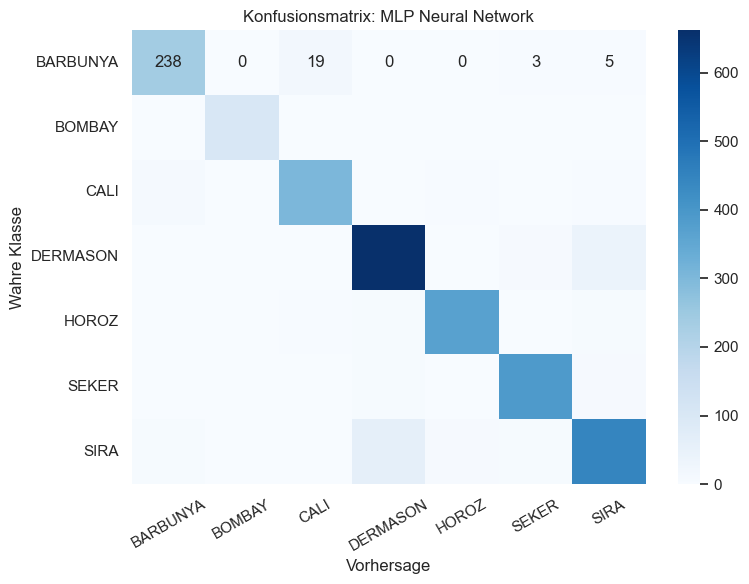

In [31]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Konfusionsmatrix: {best_model_name}")
plt.xlabel("Vorhersage")
plt.ylabel("Wahre Klasse")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("./Konfusionsmatrix.pdf", bbox_inches="tight")
plt.show()